### Caso de Uso 1: Autenticarse en el sistema


| **Elemento**          | **Descripción**                                                                                                                                 |
|-----------------------|--------------------------------------------------------------------------------------------------------------------------------------------------|
| **Nombre**            | Autenticarse en el sistema                                                                                                                       |
| **Actor principal**   | Estudiante, Administrativo, Jefe de Carrera                                                                                                      |
| **Descripción**       | Permite que el usuario ingrese al sistema proporcionando su número de carnet (o usuario) y contraseña.                                           |
| **Precondiciones**    | El usuario debe estar registrado previamente en el sistema.                                                                                      |
| **Flujo principal**   | 1. El usuario accede a la pantalla de inicio.                                                                                                    |
|                       | 2. El usuario ingresa su número de carnet o usuario y su contraseña.                                                                             |
|                       | 3. El sistema valida las credenciales.                                                                                                           |
|                       | 4. El usuario accede al sistema según su rol.                                                                                                    |
| **Flujos alternativos** | 3a. Credenciales incorrectas: El sistema muestra un mensaje de error y permite reintentar.                                                    |
| **Postcondiciones**   | El usuario queda autenticado y puede realizar operaciones según su rol.                                                                         |


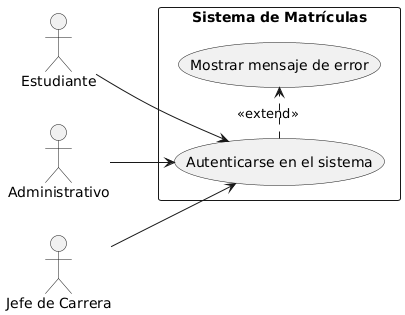

In [ ]:
# Caso de uso de matrículas #01
from plantuml import PlantUML
from IPython.display import Image

# Conexión local a PlantUML (si lo ejecutas en modo servidor) o puedes usar un servidor remoto
plantuml = PlantUML(url='http://www.plantuml.com/plantuml/img/')

uml_code = """
@startuml Autenticarse en el sistema 
left to right direction
actor Estudiante
actor Administrativo
actor "Jefe de Carrera" as Jefe

rectangle "Sistema de Matrículas" {
    usecase "Autenticarse en el sistema" as UC1
    usecase "Mostrar mensaje de error" as UC2
}

Estudiante --> UC1
Administrativo --> UC1
Jefe --> UC1

UC1 .> UC2 : <<extend>>
@enduml
"""

# Generar la imagen desde el servidor y mostrarla en el notebook
Image(plantuml.processes(uml_code))


### Caso de Uso 2: Consultar oferta académica

| **Elemento**           | **Descripción**                                                                                                                                |
|------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------|
| **Nombre**             | Consultar oferta académica                                                                                                                     |
| **Actor principal**    | Estudiante                                                                                                                                     |
| **Descripción**        | Permite al estudiante consultar las asignaturas disponibles para su carrera, sede y ciclo activo.                                             |
| **Precondiciones**     | El estudiante debe estar autenticado y el período de matrícula debe estar abierto.                                                             |
| **Flujo principal**    | 1. El estudiante selecciona la opción "Oferta Académica".                                                                                      |
|                        | 2. El sistema muestra la lista de asignaturas disponibles para su carrera.                                                                    |
|                        | 3. El estudiante puede ver detalles de cada asignatura: nombre, código, horario, docente, cupos disponibles.                                  |
| **Flujos alternativos**| No hay asignaturas disponibles: El sistema muestra un mensaje indicando que no hay materias abiertas.                                          |
| **Postcondiciones**    | El estudiante puede proceder a seleccionar asignaturas para matrícula.                                                                         |


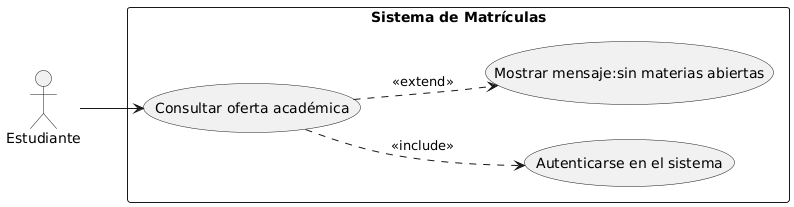

In [3]:
# Caso de uso de matrículas #02
from plantuml import PlantUML
from IPython.display import Image

# Conexión local a PlantUML (si lo ejecutas en modo servidor) o puedes usar un servidor remoto
plantuml = PlantUML(url='http://www.plantuml.com/plantuml/img/')

uml_code = """
@startuml ConsultarOfertaAcademica
left to right direction
actor Estudiante

rectangle "Sistema de Matrículas" {
    
    usecase "Autenticarse en el sistema" as UC1
    usecase "Consultar oferta académica" as UC2
    usecase "Mostrar mensaje:sin materias abiertas" as UC3

    ' Control de posición visual
    UC1 -[hidden]-> UC2
    UC2 -[hidden]-> UC3
}

Estudiante --> UC2
UC2 .> UC3 : <<extend>>
UC2 .> UC1 : <<include>>
@enduml

"""

# Generar la imagen desde el servidor y mostrarla en el notebook
Image(plantuml.processes(uml_code))

### Caso de Uso 3: Matricular asignaturas

| **Elemento**           | **Descripción**                                                                                                                                   |
|------------------------|----------------------------------------------------------------------------------------------------------------------------------------------------|
| **Nombre**             | Matricular asignaturas                                                                                                                            |
| **Actor principal**    | Estudiante                                                                                                                                        |
| **Descripción**        | Permite al estudiante seleccionar y confirmar la matrícula de sus asignaturas para el ciclo activo.                                              |
| **Precondiciones**     | Estar autenticado, tener acceso a la oferta académica, y no tener deudas pendientes (en fase futura).                                             |
| **Flujo principal**    | 1. El estudiante selecciona las asignaturas deseadas.                                                                                             |
|                        | 2. El sistema verifica disponibilidad de cupos.                                                                                                   |
|                        | 3. El estudiante confirma su selección.                                                                                                           |
|                        | 4. El sistema registra la matrícula.                                                                                                              |
| **Flujos alternativos**| 2a. Sin cupos disponibles: El sistema informa y no permite seleccionar esa sección.                                                               |
|                        | 3a. Excede máximo de materias: El sistema informa que no puede matricular más de 6 asignaturas.                                                  |
| **Postcondiciones**    | La matrícula queda registrada en el sistema. El estudiante puede visualizar su constancia.                                                        |


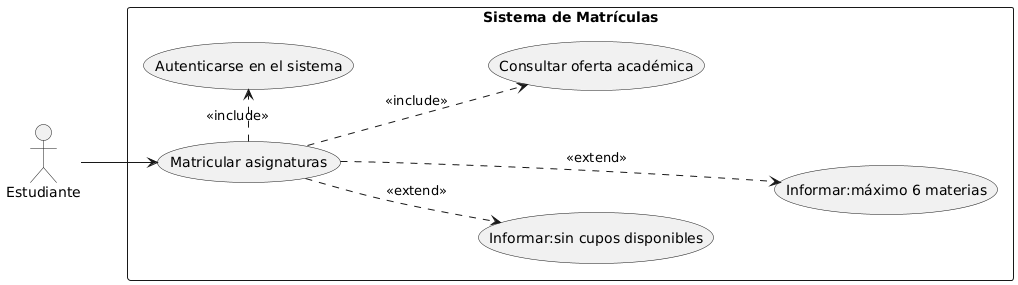

In [4]:
# Caso de uso de matrículas #03
from plantuml import PlantUML
from IPython.display import Image

# Conexión local a PlantUML (si lo ejecutas en modo servidor) o puedes usar un servidor remoto
plantuml = PlantUML(url='http://www.plantuml.com/plantuml/img/')

uml_code = """
@startuml MatricularAsignaturas
left to right direction
actor Estudiante

rectangle "Sistema de Matrículas" {

    usecase "Autenticarse en el sistema" as UC1
    usecase "Consultar oferta académica" as UC2
    usecase "Matricular asignaturas" as UC3
    usecase "Informar:sin cupos disponibles" as UC4
    usecase "Informar:máximo 6 materias" as UC5

    ' Organización visual
    UC1 -[hidden]-> UC2
    UC2 -[hidden]-> UC3
    UC3 -[hidden]-> UC4
    UC4 -[hidden]-> UC5
}

Estudiante --> UC3
UC3 .> UC1 : <<include>>
UC3 .> UC2 : <<include>>
UC3 .> UC4 : <<extend>>
UC3 .> UC5 : <<extend>>
@enduml
"""

# Generar la imagen desde el servidor y mostrarla en el notebook
Image(plantuml.processes(uml_code))

## Caso de Uso 4: Modificar matrícula

| **Elemento**         | **Descripción**                                                                                                         |
|----------------------|-------------------------------------------------------------------------------------------------------------------------|
| **Nombre**           | Modificar matrícula                                                                                                     |
| **Actor principal**  | Estudiante                                                                                                              |
| **Descripción**      | Permite al estudiante cancelar o agregar asignaturas durante el período permitido.                                     |
| **Precondiciones**   | Tener una matrícula registrada y estar dentro del período de modificación.                                              |
| **Flujo principal**  | 1. El estudiante accede a "Modificar Matrícula".<br>2. El estudiante puede eliminar asignaturas ya registradas o agregar nuevas.<br>3. El sistema actualiza el registro de matrícula. |
| **Flujos alternativos** | 2a. Si el período de modificación ha cerrado, el sistema no permite cambios.                                             |
| **Postcondiciones**  | La matrícula queda actualizada según las modificaciones del estudiante.                                                 |


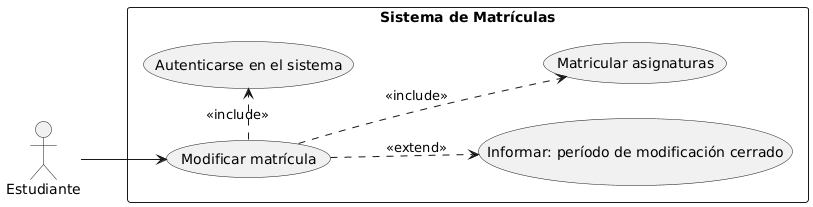

In [1]:
# Caso de uso de matrículas #04
from plantuml import PlantUML
from IPython.display import Image

# Conexión local a PlantUML (si lo ejecutas en modo servidor) o puedes usar un servidor remoto
plantuml = PlantUML(url='http://www.plantuml.com/plantuml/img/')

uml_code = """
@startuml Modificar Matricula
left to right direction
actor Estudiante

rectangle "Sistema de Matrículas" {
    usecase "Autenticarse en el sistema" as UC1
    usecase "Matricular asignaturas" as UC2
    usecase "Modificar matrícula" as UC3
    usecase "Informar: período de modificación cerrado" as UC4
}

Estudiante --> UC3

' Include necesarios
UC3 .> UC1 : <<include>>
UC3 .> UC2 : <<include>>

' Extend para flujo alternativo
UC3 .> UC4 : <<extend>>

' Organización visual
UC1 -[hidden]-> UC2
UC2 -[hidden]-> UC3
UC3 -[hidden]-> UC4
@enduml
"""

# Generar la imagen desde el servidor y mostrarla en el notebook
Image(plantuml.processes(uml_code))


## Caso de Uso 5: Gestionar períodos de matrícula

| **Elemento**         | **Descripción**                                                                                                 |
|----------------------|-----------------------------------------------------------------------------------------------------------------|
| **Nombre**           | Gestionar períodos de matrícula                                                                                 |
| **Actor principal**  | Administrativo de Registro Académico                                                                            |
| **Descripción**      | Permite a los administrativos abrir, editar o cerrar períodos de matrícula.                                    |
| **Precondiciones**   | Estar autenticado como administrativo.                                                                          |
| **Flujo principal**  | 1. El administrativo accede a la opción "Gestión de Períodos".<br>2. Crea un nuevo período o edita uno existente.<br>3. Define fechas de inicio y cierre. |
| **Flujos alternativos** | 2a. Fechas inválidas: El sistema no permite guardar fechas inconsistentes.                                      |
| **Postcondiciones**  | Un nuevo período de matrícula es registrado o actualizado.                                                     |


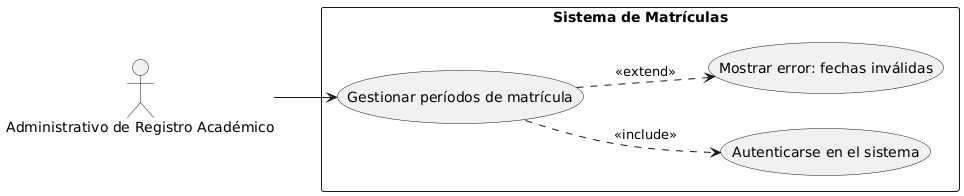

In [1]:
# Caso de uso de matrículas #05
from plantuml import PlantUML
from IPython.display import Image

# Conexión local a PlantUML (si lo ejecutas en modo servidor) o puedes usar un servidor remoto
plantuml = PlantUML(url='http://www.plantuml.com/plantuml/img/')

uml_code = """
@startuml GestionarPeriodos

left to right direction
actor "Administrativo de Registro Académico" as Administrativo

rectangle "Sistema de Matrículas" {
    usecase "Autenticarse en el sistema" as UC1
    usecase "Gestionar períodos de matrícula" as UC2
    usecase "Mostrar error: fechas inválidas" as UC3
}

Administrativo --> UC2

UC2 .> UC1 : <<include>>
UC2 .> UC3 : <<extend>>

' Organización visual
UC1 -[hidden]-> UC2
UC2 -[hidden]-> UC3

@enduml
"""

# Generar la imagen desde el servidor y mostrarla en el notebook
Image(plantuml.processes(uml_code))

## Caso de Uso 6: Asignar cupos a asignaturas

| **Elemento**            | **Descripción**                                                                                                 |
|-------------------------|-----------------------------------------------------------------------------------------------------------------|
| **Nombre**              | Asignar cupos a asignaturas                                                                                     |
| **Actor principal**     | Jefe de Carrera                                                                                                 |
| **Descripción**         | Permite definir la cantidad máxima de estudiantes que puede inscribirse en cada sección de las asignaturas.     |
| **Precondiciones**      | Tener asignaturas activadas para el ciclo actual.                                                               |
| **Flujo principal**     | 1. El jefe de carrera accede a la lista de asignaturas.<br>2. Asigna un número de cupos por sección.<br>3. Guarda los cambios en el sistema. |
| **Flujos alternativos** | 2a. Cupo menor que estudiantes preinscritos: El sistema alerta y solicita ajustes.                              |
| **Postcondiciones**     | Los cupos quedan registrados para el proceso de matrícula.                                                      |


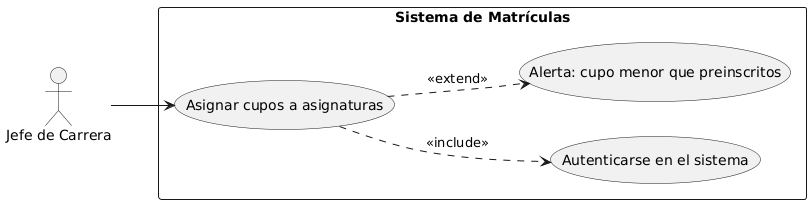

In [2]:
# Caso de uso de matrículas #06
from plantuml import PlantUML
from IPython.display import Image

# Conexión local a PlantUML (si lo ejecutas en modo servidor) o puedes usar un servidor remoto
plantuml = PlantUML(url='http://www.plantuml.com/plantuml/img/')

uml_code = """
@startuml AsignarCupos

left to right direction
actor "Jefe de Carrera" as Jefe

rectangle "Sistema de Matrículas" {
    usecase "Autenticarse en el sistema" as UC1
    usecase "Asignar cupos a asignaturas" as UC2
    usecase "Alerta: cupo menor que preinscritos" as UC3
}

Jefe --> UC2

UC2 .> UC1 : <<include>>
UC2 .> UC3 : <<extend>>

' Organización visual
UC1 -[hidden]-> UC2
UC2 -[hidden]-> UC3

@enduml

"""

# Generar la imagen desde el servidor y mostrarla en el notebook
Image(plantuml.processes(uml_code))

## Caso de Uso 7: Generar reportes de matrícula

| **Elemento**            | **Descripción**                                                                                              |
|-------------------------|--------------------------------------------------------------------------------------------------------------|
| **Nombre**              | Generar reportes de matrícula                                                                                |
| **Actor principal**     | Administrativo de Registro Académico, Jefe de Carrera                                                        |
| **Descripción**         | Permite visualizar informes detallados de matrícula por carrera, sede, y ciclo.                              |
| **Precondiciones**      | El actor debe estar autenticado y tener permisos para acceder a reportes.                                    |
| **Flujo principal**     | 1. El actor selecciona criterios de reporte (carrera, sede, ciclo).<br>2. El sistema genera el reporte.<br>3. El actor puede exportarlo en formatos como PDF o Excel. |
| **Flujos alternativos** | No hay datos para los criterios seleccionados: Se muestra un mensaje de "No existen registros".              |
| **Postcondiciones**     | El reporte es generado exitosamente.                                                                         |


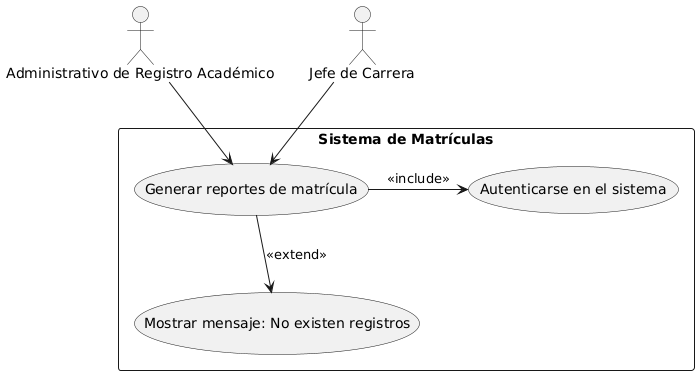

In [3]:
# Caso de uso de matrículas #07
from plantuml import PlantUML
from IPython.display import Image

# Conexión local a PlantUML (si lo ejecutas en modo servidor) o puedes usar un servidor remoto
plantuml = PlantUML(url='http://www.plantuml.com/plantuml/img/')

uml_code = """
@startuml GenerarReportes

actor "Administrativo de Registro Académico" as Adm
actor "Jefe de Carrera" as Jefe

rectangle "Sistema de Matrículas" {
    usecase "Generar reportes de matrícula" as UC2
    usecase "Autenticarse en el sistema" as UC1
    usecase "Mostrar mensaje: No existen registros" as UC3
}

Adm --> UC2
Jefe --> UC2

' Organizar explícitamente las posiciones
UC2 -right-> UC1 : <<include>>
UC2 -down-> UC3 : <<extend>>

@enduml
"""

# Generar la imagen desde el servidor y mostrarla en el notebook
Image(plantuml.processes(uml_code))